# 13. Autonomous Agentic RAG with LangGraph

**RAG Pipeline Series — Notebook 13**

[Notebook 12](12_agentic_rag_with_tools.ipynb) turned retrieval into a tool the model could call, and wrote a small `while`-loop by hand to run the agent: invoke the model, check for `tool_calls`, run them, feed the results back, repeat. That loop *works*, but it has two limits baked in by how it was written:

1. **No memory between questions.** Every call to `rag_agent_answer()` starts a brand-new `messages` list. Ask a follow-up like "what about the second one you mentioned?" and the agent has no idea what "the second one" refers to — the previous turn is gone.
2. **The orchestration logic is invisible.** The control flow (call model → maybe call tools → maybe call model again) lives inside a Python `for` loop. It works, but there's no structure a framework — or a diagram — can reason about.

This notebook rebuilds the same agent as an explicit graph using **[LangGraph](https://langchain-ai.github.io/langgraph/)**, LangChain's library for orchestrating stateful, multi-step agents. Nothing about the *use case* changes — same chatbot, same two tools (`search_rag_document`, `web_search`), same Gemini model. What changes is how the orchestration is expressed and what that buys:

- The agent loop from notebook 12 becomes two **nodes** (`agent`, `tools`) connected by a **conditional edge** that LangGraph evaluates after every model call — the same decision the `for` loop made by hand, now declared rather than coded.
- A **checkpointer** (`MemorySaver`) gives the graph persistent memory *per conversation thread*, so a follow-up question can refer back to an earlier answer in the same session — something notebook 12's stateless loop could not do.
- The Gradio UI upgrades from a single question/answer box to a real multi-turn **chat** (`gr.ChatInterface`), because there's now a conversation to have.

This is the pattern most production agent frameworks converge on: an explicit graph of nodes and edges over a shared state, rather than a hand-rolled loop. The notebook is written to run standalone in Google Colab as well as locally.

## Setup

In [ ]:
%pip install -q -U langchain langchain-community langchain-core langchain-text-splitters sentence-transformers langchain-huggingface langchain-chroma chromadb langchain-google-genai langgraph python-dotenv gradio ddgs

### Files this notebook needs

- `rag.pdf` — the source document (same as every other notebook in the series).
- `.env` — must contain a `GOOGLE_API_KEY` for Gemini. Get a free key from [Google AI Studio](https://aistudio.google.com/apikey); the `gemini-2.5-flash` model used below is available on the free tier.

No key is needed for web search — `ddgs` queries DuckDuckGo directly, without an API key.

In Colab neither file exists on the VM yet, so the cell below opens a file picker twice — once for `rag.pdf`, once for `.env` — via the same `maybe_colab_upload()` helper the series already uses. Locally, both files already sit next to this notebook, so the picker is skipped.

In [ ]:
from rag_utils import maybe_colab_upload

# Only runs inside Colab. Opens a file picker each time; select rag.pdf, then .env.
# Safe to skip this cell if you're running locally and already have both files on disk.
maybe_colab_upload()  # -> rag.pdf
maybe_colab_upload()  # -> .env

In [1]:
import os
from pathlib import Path

from dotenv import load_dotenv

# Colab uploads land in /content; locally the .env sits next to this notebook.
env_path = "/content/.env" if os.path.exists("/content/.env") else ".env"
assert os.path.exists(env_path), "Could not find .env - upload it first (see cell above)."
load_dotenv(env_path)

assert os.environ.get("GOOGLE_API_KEY"), "GOOGLE_API_KEY not set - check your .env file."
print("GOOGLE_API_KEY loaded.")

GOOGLE_API_KEY loaded.


## 1. Rebuild the retriever

Same pipeline as notebooks 7-12: load `rag.pdf`, strip headers/footers, chunk chapter-by-chapter, embed with the series' `sentence-transformers/paraphrase-MiniLM-L3-v2` model, and index into an in-memory Chroma store.

In [2]:
from rag_utils import build_chroma_store, get_embedder, load_chapter_chunks

pages, full_text, chapters, chunks = load_chapter_chunks()

embeddings = get_embedder()
vectorstore = build_chroma_store(chunks, embeddings=embeddings, collection_name="rag_pdf_chapters")
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

print(f"{len(chunks)} chunks indexed; retriever returns top 5 matches per query")

d:\youtube\TheAIGuy\RAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 55/55 [00:00<00:00, 3503.06it/s]


181 chunks indexed; retriever returns top 5 matches per query


## 2. Tools

Identical to notebook 12: `search_rag_document` wraps the `retriever` built above, `web_search` wraps a key-less DuckDuckGo text search via `ddgs`. Both log what they did into `tool_call_log` so the UI can show which tool(s) fired on a given turn.

In [3]:
from langchain_core.tools import tool

tool_call_log = []  # cleared per turn in run_agent_turn(); UI reads this for transparency


def format_context(docs):
    return "\n\n".join(
        f"[Chapter {d.metadata['chapter_num']}: {d.metadata['chapter_title']}]\n{d.page_content}"
        for d in docs
    )


@tool
def search_rag_document(query: str) -> str:
    """Search rag.pdf, the RAG course document, for relevant passages.

    Use this for any question about RAG concepts covered in the course: chunking,
    embeddings, vector stores, keyword/dense/hybrid retrieval, re-ranking,
    augmentation, or generation. Always try this tool first for conceptual
    questions about RAG - it is the authoritative source for the course material.
    """
    docs = retriever.invoke(query)
    result = format_context(docs)
    tool_call_log.append({
        "tool": "search_rag_document",
        "query": query,
        "summary": ", ".join(f"Chapter {d.metadata['chapter_num']}" for d in docs),
    })
    return result


@tool
def web_search(query: str) -> str:
    """Search the live web for current information that rag.pdf would not contain.

    Use this for questions about recent events, current facts, or any topic outside
    the RAG course document - anything time-sensitive or not related to RAG concepts.
    """
    from ddgs import DDGS

    with DDGS() as ddgs:
        results = list(ddgs.text(query, max_results=3))

    tool_call_log.append({
        "tool": "web_search",
        "query": query,
        "summary": ", ".join(r["title"] for r in results) if results else "no results",
    })

    if not results:
        return "No web results found."
    return "\n\n".join(f"{r['title']}\n{r['body']}\nSource: {r['href']}" for r in results)


TOOLS = [search_rag_document, web_search]

## 3. Binding tools to Gemini

Same as notebook 12: `llm.bind_tools(TOOLS)` returns a runnable that may respond with `tool_calls` instead of (or alongside) plain text. The model decides whether to call a tool; nothing here forces it.

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-3-flash-preview", temperature=0.2)
llm_with_tools = llm.bind_tools(TOOLS)

## 4. The graph

Notebook 12's `for` loop encoded three ideas: "call the model", "check whether it asked for tools", and "run them and go again". LangGraph makes each of those an explicit piece of a graph built on a shared **state**:

- **State** — `MessagesState`, a built-in LangGraph state shape that is just `{"messages": [...]}`, where new messages are *appended* to the list (via the `add_messages` reducer) rather than overwriting it. That reducer is what makes the conversation cumulative across turns instead of reset each time.
- **`agent` node** — calls `llm_with_tools.invoke(state["messages"])` and returns the response to be appended to `messages`. This is the "call the model" step from the old loop.
- **`tools` node** — LangGraph's prebuilt `ToolNode(TOOLS)`. It looks at the last message for `tool_calls`, runs the matching tool(s) locally, and appends the results back as `ToolMessage`s. This replaces the manual `for tool_call in ai_message.tool_calls: ...` block.
- **Conditional edge** — LangGraph's prebuilt `tools_condition` inspects the `agent` node's output: if it contains `tool_calls`, route to `tools`; otherwise route to `END`. This is the `if not ai_message.tool_calls: return ...` check from the old loop, now declared instead of coded.
- **`tools -> agent` edge** — after running tools, control always goes back to `agent` so the model can see the results and decide what to do next (call another tool, or answer). This is the "go again" part of the old loop.

The piece notebook 12 didn't have: a **checkpointer**. `MemorySaver()` persists the state after every node runs, keyed by a `thread_id` passed in at invoke time. Two invocations with the same `thread_id` share history; different `thread_id`s are completely isolated conversations. That's what turns this from a one-shot tool user into an agent with memory.

In [5]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition


def agent_node(state: MessagesState):
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}


builder = StateGraph(MessagesState)
builder.add_node("agent", agent_node)
builder.add_node("tools", ToolNode(TOOLS))

builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", tools_condition)  # -> "tools" if tool_calls, else END
builder.add_edge("tools", "agent")

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

A quick look at the graph's structure - `draw_mermaid()` renders it as Mermaid text with no network call, so it's always safe to run. The optional cell after it renders an actual diagram image via the public mermaid.ink API, which needs internet access and may not work in every environment - it's best-effort and safe to skip.

In [6]:
print(graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	agent(agent)
	tools(tools)
	__end__([<p>__end__</p>]):::last
	__start__ --> agent;
	agent -.-> __end__;
	agent -.-> tools;
	tools --> agent;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



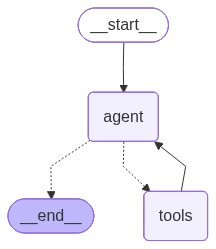

In [7]:
try:
    from IPython.display import Image, display

    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Skipping graph image (needs internet access to mermaid.ink): {e}")

## 5. The agent loop: `run_agent_turn()`

Where notebook 12's `rag_agent_answer()` cleared `messages` on every call, `run_agent_turn()` only supplies a `SystemMessage` the *first* time a given `thread_id` is used - `graph.get_state(config)` comes back empty for a thread LangGraph hasn't seen yet. After that, only the new `HumanMessage` is sent in; the checkpointer already has everything before it, and `MessagesState`'s reducer appends rather than replaces.

`recursion_limit` is the LangGraph equivalent of notebook 12's `max_steps` safety valve - it caps how many times the graph can step through `agent -> tools -> agent -> ...` before giving up, so a model that never stops calling tools can't loop forever.

In [8]:
from langchain_core.messages import HumanMessage, SystemMessage

AGENT_SYSTEM_PROMPT = (
    "You are a helpful assistant that answers questions using tools.\n"
    "- For questions about RAG concepts (chunking, retrieval, embeddings, re-ranking, "
    "augmentation, generation), call search_rag_document first.\n"
    "- For questions about current events, facts, or anything outside the RAG course "
    "document, call web_search.\n"
    "- If search_rag_document doesn't contain the answer, try web_search before giving up.\n"
    "- Answer only from tool results - do not rely on outside knowledge you were not given "
    "by a tool. Mention which tool(s) and, if applicable, which chapter(s) your answer came from.\n"
    "- You may be shown earlier turns from this same conversation - use them for context on "
    "follow-up questions (e.g. \"the second one\", \"what about that chapter\")."
)


def run_agent_turn(question, thread_id, max_steps=8):
    tool_call_log.clear()
    config = {"configurable": {"thread_id": thread_id}, "recursion_limit": 2 * max_steps + 1}

    is_new_thread = not graph.get_state(config).values
    input_messages = [HumanMessage(content=question)]
    if is_new_thread:
        input_messages = [SystemMessage(content=AGENT_SYSTEM_PROMPT)] + input_messages

    result = graph.invoke({"messages": input_messages}, config)
    return result["messages"][-1].content, list(tool_call_log)

Try it with two questions on the *same* `thread_id`: one squarely inside `rag.pdf`, then a follow-up that only makes sense if the agent remembers the first answer - something notebook 12's stateless loop could not have handled.

In [9]:
demo_thread = "demo-thread-1"

answer, log = run_agent_turn("What is re-ranking used for in a RAG pipeline?", demo_thread)
print("ANSWER:\n", answer)
print("\nTOOL CALLS:")
for entry in log:
    print(f"  - {entry['tool']}({entry['query']!r}) -> {entry['summary']}")

ANSWER:
 [{'type': 'text', 'text': 'According to Chapter 8 of the RAG course document, re-ranking is used as the second stage of a **multi-stage retrieval pipeline** to improve the precision of the results.\n\nThe process works as a "funnel":\n*   **Stage 1 (Recall-focused):** A fast retriever (like BM25 or vector search) quickly pulls a large set of potential candidates (e.g., top 100 or 500).\n*   **Stage 2 (Precision-focused):** A more powerful and computationally expensive **cross-encoder model** re-ranks these candidates to surgically select the most relevant ones (typically the top 5 to 10).\n\nThe primary purpose of re-ranking is to achieve the "best of both worlds": the speed of a broad first-stage search combined with the high accuracy of a sophisticated model, all while staying within an acceptable latency budget.', 'extras': {'signature': 'EukHCuYHARFNMg/2K2MWj0Rnq7+Q1DbSF5DtkhBTGYnf0ou8FTieRBvZkz93O8Ducd1ZxgjLp0Dkfo5L/rtuSZuq5ipZ0PQwP3x9nV5eWsRWgs6cphVCzB1fxlL+bXfTRBOaGBb5x

In [10]:
answer, log = run_agent_turn("Which chapter did that come from, and what's the very next chapter about?", demo_thread)
print("ANSWER:\n", answer)
print("\nTOOL CALLS:")
for entry in log:
    print(f"  - {entry['tool']}({entry['query']!r}) -> {entry['summary']}")

ANSWER:
 [{'type': 'text', 'text': 'The information about re-ranking came from **Chapter 08: Re-ranking**.\n\nThe very next chapter, **Chapter 09**, is about **Augmentation**. This chapter focuses on how to select, structure, and frame retrieved information for the LLM, including context construction, prompt templates, and handling metadata.'}]

TOOL CALLS:
  - search_rag_document('Chapter 09 title topic') -> Chapter 02, Chapter 03, Chapter 09, Chapter 03, Chapter 09


A question on a *different* `thread_id` should not see any of the above - it starts from a clean state, same as a new visitor opening the chatbot for the first time.

In [11]:
answer, log = run_agent_turn("Who won the most recent Super Bowl?", "demo-thread-2")
print("ANSWER:\n", answer)
print("\nTOOL CALLS:")
for entry in log:
    print(f"  - {entry['tool']}({entry['query']!r}) -> {entry['summary']}")

ANSWER:
 [{'type': 'text', 'text': 'The **Kansas City Chiefs** won the most recent Super Bowl (Super Bowl LVIII), which took place on February 11, 2024. They defeated the San Francisco 49ers with a final score of 25–22.\n\nThis information was found using the **web_search** tool.', 'extras': {'signature': 'EuYBCuMBARFNMg+mfTUQ3Sdk9HSsFobS2PveiShUiSIOnVltwdGHHsiG6qJ8UjSVbjV7xWMYatpET/ee2kT4wB7p8ZhCYZAuoAvDOc8SJS0vgfNycq7s8B8jnmzB34sYBUGX8k1lLZ0fnhAR2ELCXdTGOhDbLKUUIpYYyMt8cZedSDOKrpm7bDCbu0fAw5YZNB0xM3fGQquPuz0o5DojZb7/kZ2gzMbEZRbzhg891kkClWmwMjE+UUx2tuFV8ftjcquF4dfDWxqMQhAymp/+9eNUr0pEESkBhCxlRl9wIZ1iAPkK7XK9ICk='}}]

TOOL CALLS:
  - web_search('who won the most recent Super Bowl') -> List of Super Bowl champions - Wikipedia, Super Bowl - Wikipedia, List of Super Bowl Winners (1967-2026) - NFL Champions by Year
  - web_search('who won Super Bowl 2024') -> Super Bowl LVIII - Wikipedia, List of Super Bowl champions - Wikipedia, List of Super Bowl Winners (1967-2026) - NFL Champions by Ye

## 6. A Gradio chat UI

Notebook 11 and 12 both used a single question box and a single answer box, because neither had any memory - each question was independent. Now that the graph carries conversation history per `thread_id`, the UI can be an actual multi-turn chat: `gr.ChatInterface`.

Each browser session gets its own `thread_id`, generated once via `gr.State(lambda: ...)` and threaded into `chat_fn` as an extra input - so two people using the same running Gradio app get independent conversations. Tool calls for a turn are appended under the answer so the agent's choices stay visible, same as notebook 12.

`demo.launch(share=True, debug=True)` is the Colab-safe way to launch: Colab can't serve a local port directly, so Gradio needs `share=True` to tunnel the UI to a public URL it prints below the cell. This works locally too - it just also opens the tunnel there.

In [14]:
import uuid

import gradio as gr


def chat_fn(message, history, thread_id):
    if not message or not message.strip():
        return "Please enter a question."

    answer, log = run_agent_turn(message, thread_id)
    if isinstance(answer, list) and len(answer) > 0:
        answer = answer[0]['text']
    elif isinstance(answer, str):
        answer = answer
    else:
        answer = "Unexpected answer format."
    if log:
        tool_lines = "\n".join(f"- {e['tool']}({e['query']!r}) -> {e['summary']}" for e in log)
        return f"{answer}\n\n---\n**Tools used:**\n{tool_lines}"
    return f"{answer}\n\n---\n*(no tools called - answered directly)*"


def new_thread_id():
    return str(uuid.uuid4())


with gr.Blocks(title="Autonomous Agentic RAG over rag.pdf + the web") as demo:
    gr.Markdown(
        "# Chat with rag.pdf (or the web)\n"
        "A LangGraph agent decides, per message, whether to search the notebook 1-10 "
        "retriever, search the web, both, or neither - and remembers earlier turns in "
        "this conversation."
    )

    thread_state = gr.State(new_thread_id)

    chatbot_ui = gr.ChatInterface(
        fn=chat_fn,
        additional_inputs=[thread_state],
        # type="messages",
    )

    reset_btn = gr.Button("Start a new conversation")
    reset_btn.click(fn=new_thread_id, outputs=thread_state)
    reset_btn.click(fn=lambda: None, outputs=chatbot_ui.chatbot)

demo.launch(share=True, debug=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://d71e75976b3df72d6c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://d71e75976b3df72d6c.gradio.live


## Takeaways

- A hand-rolled agent loop and a LangGraph graph express the *same* control flow - call model, maybe call tools, maybe call model again - but the graph declares it as nodes and edges over a shared state instead of burying it in a `for` loop.
- `MessagesState` + `add_messages` makes conversation history additive by default; a `MemorySaver` checkpointer persists that history per `thread_id`, so an agent can carry context across turns without any hand-written history management.
- `ToolNode` and `tools_condition` are prebuilt replacements for the two pieces of notebook 12's loop that had nothing to do with RAG specifically - running requested tools, and deciding whether to run them at all.
- Retrieval's role doesn't change from notebook 12 - `search_rag_document` is still just one tool among others. What changes is the orchestration around it: explicit, inspectable, and now stateful across a whole conversation.
- The user-facing shape changes to match what's now possible: a single Q&A box becomes a real chat, because there's finally a conversation to have.

This is the same pattern most production agent frameworks - including LangGraph itself - are built around: a graph of nodes and edges over shared state, with persistence handled by a checkpointer rather than application code.